## Return Map (Lorenz System)

This section analyzes the relationship between successive maxima to assess the learned dynamics of the NG-RC model.

In [1]:
# LorenzConstLinQuadraticNVARtimedelayReturnMap-RK23.py

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.signal
import scipy.interpolate
import matplotlib.patches

In [2]:
## Parameters

# Time step of numerical integration
dt = 0.025

# Warm-up time (no training; allows transients to decay)
warmup = 5.0

# Training duration (used to learn output weights)
traintime = 10.0

# Testing duration (model prediction phase)
testtime = 1000.0

# Total simulation time
maxtime = warmup + traintime + testtime

# Portion of test duration shown in plots
plottime = 20.0

# Lyapunov time of the Lorenz system (predictability scale)
lyaptime = 1.104


In [3]:
# Convert time durations to discrete sample counts

warmup_pts    = round(warmup / dt)        # Number of warm-up samples
traintime_pts = round(traintime / dt)     # Number of training samples
warmtrain_pts = warmup_pts + traintime_pts  # Samples before prediction
testtime_pts  = round(testtime / dt)      # Number of testing samples
maxtime_pts   = round(maxtime / dt)       # Total number of samples
plottime_pts  = round(plottime / dt)      # Samples shown in plots
lyaptime_pts  = round(lyaptime / dt)      # Lyapunov time in samples

# Display computed sample counts
print("warmup_pts    =", warmup_pts)
print("traintime_pts =", traintime_pts)
print("warmtrain_pts =", warmtrain_pts)
print("testtime_pts  =", testtime_pts)
print("maxtime_pts   =", maxtime_pts)
print("plottime_pts  =", plottime_pts)
print("lyaptime_pts  =", lyaptime_pts)

warmup_pts    = 200
traintime_pts = 400
warmtrain_pts = 600
testtime_pts  = 40000
maxtime_pts   = 40600
plottime_pts  = 800
lyaptime_pts  = 44


In [4]:
# NVAR feature parameters

d = 3                 # Input dimension (x, y, z)
k = 2                 # Number of time delay 

dlin = k * d          # Linear feature dimension
dnonlin = int(dlin * (dlin + 1) / 2)  # Quadratic feature dimension

dtot = 1 + dlin + dnonlin  # Total feature dimension (constant + linear + quadratic)

# Display feature dimensions
print("d       =", d)
print("k       =", k)
print("dlin    =", dlin)
print("dnonlin =", dnonlin)
print("dtot    =", dtot)

d       = 3
k       = 2
dlin    = 6
dnonlin = 21
dtot    = 28


In [5]:
# Ridge regression parameter (regularization strength)
ridge_param = 2.5e-6

# Time grid for full simulation interval
# (maxtime_pts + 1 ensures spacing of dt)
t_eval = np.linspace(0, maxtime, maxtime_pts + 1)

In [6]:
# Lorenz–63 parameters
sigma = 10
beta = 8 / 3
rho = 28

# Lorenz system definition
def lorenz(t, y):
    """
    Computes time derivatives for the Lorenz-63 system.
    
    Parameters:
        t : float
            Current time (required by solve_ivp)
        y : array-like
            State vector [x, y, z]
            
    Returns:
        list
            Time derivatives [dx/dt, dy/dt, dz/dt]
    """
    
    dx = sigma * (y[1] - y[0])
    dy = y[0] * (rho - y[2]) - y[1]
    dz = y[0] * y[1] - beta * y[2]
    
    return [dx, dy, dz]


In [7]:
# Integrate the Lorenz system to generate time-series data
# Initial condition lies on the attractor to ensure typical chaotic dynamics

lorenz_soln = solve_ivp(
    lorenz,                         # Lorenz system function
    (0, maxtime),                   # Time interval
    [17.67715816276679,
     12.931379185960404,
     43.91404334248268],            # Initial state [x0, y0, z0]
    t_eval=t_eval,                  # Discrete evaluation times
    method='RK23'                   # Runge–Kutta method
)

print("Solution status:", lorenz_soln.message)
print("State array shape:", lorenz_soln.y.shape)

Solution status: The solver successfully reached the end of the integration interval.
State array shape: (3, 40601)


In [8]:
# Compute total variance across all state variables (x, y, z)
# Used later to normalize prediction error
total_var = np.var(lorenz_soln.y[0:d, :])

print("Total variance =", total_var)

Total variance = 196.4845722253977


In [9]:
# Compute basic statistics (mean, min, max) for each Lorenz variable

lorenz_stats = np.zeros((3, 3))  # rows: [mean, min, max], cols: [x, y, z]

for i in range(3):
    # Mean over evaluation region (after training)
    lorenz_stats[0, i] = np.mean(
        lorenz_soln.y[i, warmtrain_pts:maxtime_pts]
    )

    # Minimum value
    lorenz_stats[1, i] = np.min(
        lorenz_soln.y[i, warmtrain_pts:maxtime_pts]
    )

    # Maximum value
    lorenz_stats[2, i] = np.max(
        lorenz_soln.y[i, warmtrain_pts:maxtime_pts]
    )

In [10]:
# Construct linear (delay) feature matrix

# Array to store linear + delayed features
# Shape: (dlin, total_time_steps)
x = np.zeros((dlin, maxtime_pts))

# Fill features:
# For each delay, stack shifted versions of the Lorenz state
for delay in range(k):
    for j in range(delay, maxtime_pts):
        x[d*delay:d*(delay+1), j] = lorenz_soln.y[:, j - delay]

print("Linear feature matrix shape:", x.shape)

Linear feature matrix shape: (6, 40600)


In [11]:
# Construct training feature matrix (bias + linear features)

# Initialize feature matrix
# First row = bias (constant 1), remaining rows will hold features
out_train = np.ones((dtot, traintime_pts))

# Insert linear (current + delayed) features
# Use indices after warm-up to avoid transient effects
out_train[1:dlin+1, :] = x[:, warmup_pts-1:warmtrain_pts-1]

print("Training feature matrix shape:", out_train[1:dlin+1, :].shape)

Training feature matrix shape: (6, 400)


In [12]:
# Construct nonlinear (quadratic) features for training

cnt = 0  # Counter for quadratic feature index

# Loop over all pairs of linear features (with repetition)
for i in range(dlin):
    for j in range(i, dlin):

        # Create quadratic terms: x_i * x_j
        out_train[dlin + 1 + cnt, :] = (
            x[i, warmup_pts-1:warmtrain_pts-1] *
            x[j, warmup_pts-1:warmtrain_pts-1]
        )

        cnt += 1
        

print("Nonlinear features added:", cnt)
print("Final training matrix shape:", out_train.shape)

Nonlinear features added: 21
Final training matrix shape: (28, 400)


In [13]:
# Construct training target (state increment)
# Target = difference between consecutive Lorenz states

Y = (
    x[0:d, warmup_pts:warmtrain_pts]
    - x[0:d, warmup_pts-1:warmtrain_pts-1]
)

# print("Target matrix shape:", Y.shape)


# Ridge regression to compute output weights
# Learns mapping: features → state increment

W_out = (
    Y @ out_train.T @
    np.linalg.pinv(
        out_train @ out_train.T +
        ridge_param * np.identity(dtot)
    )
)

print("Output weight matrix shape:", W_out.shape)

Output weight matrix shape: (3, 28)


In [14]:
# Predict training data using learned weights

# One-step prediction:
# next state = current state + predicted increment
x_predict = (
    x[0:d, warmup_pts-1:warmtrain_pts-1] +
    W_out @ out_train[:, :traintime_pts]
)

print("Training prediction shape:", x_predict.shape)

Training prediction shape: (3, 400)


In [15]:
# Training error (NRMSE)

# Compute difference between true and predicted states
error = x[0:d, warmup_pts:warmtrain_pts] - x_predict

# Normalize error using total variance
rms = np.sqrt(np.mean(error**2) / total_var)

print("Training NRMSE:", rms)

Training NRMSE: 0.00010470292391195097


In [16]:
# Feature vector for one time step
out_test = np.zeros(dtot)

# Matrix to store predicted states during testing
x_test = np.zeros((dlin, testtime_pts))

# Initialize with final training state
x_test[:, 0] = x[:, warmtrain_pts - 1]

In [17]:
# Autonomous prediction (testing phase)

for j in range(testtime_pts - 1):

    # Insert linear features (current state + delays)
    out_test[1:dlin+1] = x_test[:, j]

    # Construct quadratic features from linear terms
    cnt = 0
    for row in range(dlin):
        for column in range(row, dlin):

            out_test[dlin + 1 + cnt] = (
                x_test[row, j] * x_test[column, j]
            )

            cnt += 1

    # Shift delay taps (move past states forward)
    x_test[d:dlin, j+1] = x_test[0:(dlin - d), j]

    # Predict next state using learned increment
    x_test[0:d, j+1] = (
        x_test[0:d, j] + W_out @ out_test
    )


# Compute NRMSE over one Lyapunov time

# True vs predicted segments
true_segment = x[0:d,
    warmtrain_pts-1 : warmtrain_pts+lyaptime_pts-1]

pred_segment = x_test[0:d, 0:lyaptime_pts]

# Normalize error
test_nrmse = np.sqrt(
    np.mean((true_segment - pred_segment)**2) / total_var
)

print("Test prediction shape:", x_test.shape)
print("Lyapunov window length:", lyaptime_pts)
print("Test NRMSE (1 Lyapunov time):", test_nrmse)

Test prediction shape: (6, 40000)
Lyapunov window length: 44
Test NRMSE (1 Lyapunov time): 0.0006726856035574262


In [18]:
# use interpolating splines to find maxima of input signal, and return an array
# of (M_i, M_i+1) pairs
def return_map_spline(v):
    spline = scipy.interpolate.InterpolatedUnivariateSpline(np.arange(len(v)), v, k=4)
    spline_d = spline.derivative()
    spline_dd = spline_d.derivative()

    # when is the derivative of v zero?
    extimes = spline_d.roots()

    # discard times out of bound
    extimes = extimes[extimes > 0]
    extimes = extimes[extimes < len(v) - 1]

    # select only local maxima
    extimes = extimes[spline_dd(extimes) < 0]

    # find values
    ex = spline(extimes)

    # construct return map
    return np.stack([ex[:-1], ex[1:]], axis=-1)

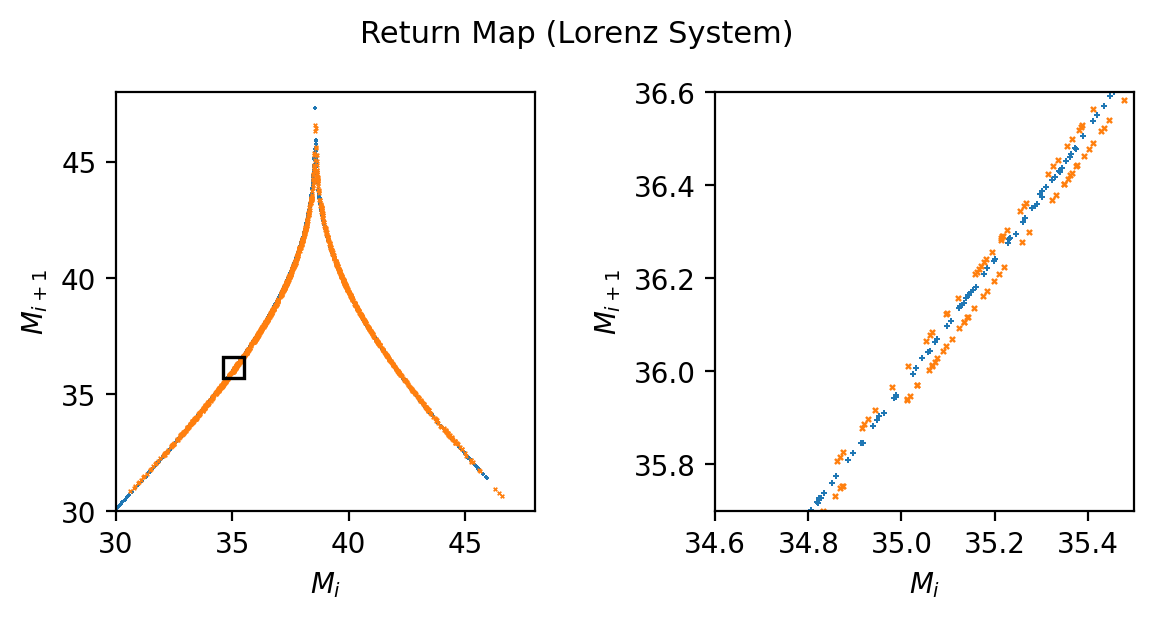

In [19]:
# Compute return maps
rm = return_map_spline(x_test[2, :])
rm_cmp = return_map_spline(lorenz_soln.y[2, :testtime_pts])


# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, dpi=200, figsize=(6, 3))


# --- Whole return map ---
ax1.scatter(
    rm_cmp[:, 0], rm_cmp[:, 1],
    marker='P',
    s=3,
    color='tab:blue',
    linewidths=0
)

ax1.scatter(
    rm[:, 0], rm[:, 1],
    marker='X',
    s=3,
    color='tab:orange',
    linewidths=0
)

ax1.set_xlim(30, 48)
ax1.set_ylim(30, 48)
ax1.set_xlabel('$M_i$')
ax1.set_ylabel('$M_{i+1}$')
ax1.set_aspect('equal', adjustable='box')


# --- Zoomed return map ---
ax2.scatter(
    rm_cmp[:, 0], rm_cmp[:, 1],
    marker='P',
    s=6,
    color='tab:blue',
    linewidths=0
)

ax2.scatter(
    rm[:, 0], rm[:, 1],
    marker='X',
    s=6,
    color='tab:orange',
    linewidths=0
)

xlim2 = (34.6, 35.5)
ylim2 = (35.7, 36.6)

ax2.set_xlim(*xlim2)
ax2.set_ylim(*ylim2)
ax2.set_xlabel('$M_i$')
ax2.set_ylabel('$M_{i+1}$')
ax2.set_aspect('equal', adjustable='box')


# --- Draw zoom box ---
rect = matplotlib.patches.Rectangle(
    (xlim2[0], ylim2[0]),
    xlim2[1] - xlim2[0],
    ylim2[1] - ylim2[0],
    linewidth=1.2,
    edgecolor='black',
    facecolor='none'
)
ax1.add_patch(rect)


# Title (optional improvement)
fig.suptitle('Return Map (Lorenz System)', fontsize=11)


# Save and show
plt.tight_layout(pad=1.0)
plt.savefig('img/lz_return_map.png', dpi=300, bbox_inches='tight')
plt.show()